In [2]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn  as sns 


In [3]:
df = pd.read_csv('StudentsPerformance.csv')
df.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [17]:
print(df.isnull().sum())
#df.drop("math score", axis=1, inplace=True)
df['math score'] = df['math score'].fillna(df['math score'].mean())
print(df['math score'])

gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
dtype: int64
0      72
1      69
2      90
3      47
4      76
       ..
995    88
996    62
997    59
998    68
999    77
Name: math score, Length: 1000, dtype: int64


In [13]:
print(df.columns.tolist())

['gender', 'race/ethnicity', 'parental level of education', 'lunch', 'test preparation course', 'math score', 'reading score', 'writing score']


In [15]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
       math score  reading score  writing score
count  1000.00000    1000.000000    1000.000000
mean     66.08900      69.169000      68.054000
std      15.16308      14.600192      15.195657
min       0.00000      17.000000      10.000000
25%      57.00000      59.000

In [11]:
df.shape

(1000, 8)

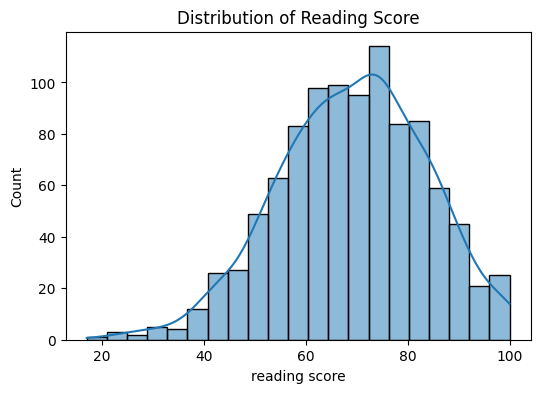

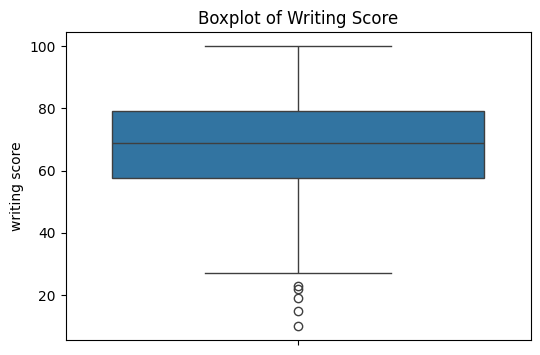

In [22]:
plt.figure(figsize=(6,4))
# (6,4) adjust siize
sns.histplot(df["reading score"], kde=True)
plt.title("Distribution of Reading Score")
plt.show()

plt.figure(figsize=(6,4))
# y vertcally x horizontally
# sns.boxplot(data=df[["math score", "reading score", "writing score"]])
sns.boxplot(y=df["writing score"])
plt.title("Boxplot of Writing Score")
plt.show()




CORRELATION MATRIX:
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000

INSIGHT: Reading and Writing scores show strong positive correlation.

CORRELATION MATRIX:
               math score  reading score  writing score
math score       1.000000       0.817580       0.802642
reading score    0.817580       1.000000       0.954598
writing score    0.802642       0.954598       1.000000


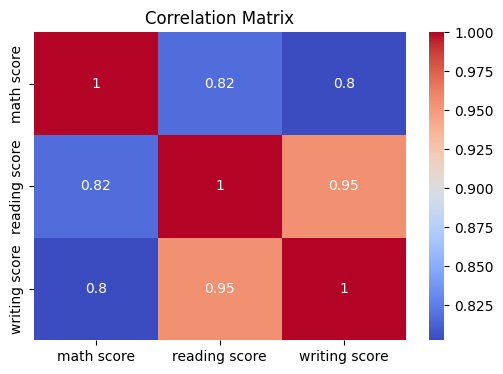

In [33]:
corr = df[["math score","reading score","writing score"]].corr()
print("\nCORRELATION MATRIX:")
print(corr)

print("\nINSIGHT: Reading and Writing scores show strong positive correlation.")


# Correlation matrix
corr = df[["math score", "reading score", "writing score"]].corr()
print("\nCORRELATION MATRIX:")
print(corr)

#Optional: heatmap visualization
plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()



In [34]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

features = ["math score","reading score","writing score"]

# Scale numeric values
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[features])

# PCA to 2 components
pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

print("\nPCA Completed. Shape:", pca_data.shape)



PCA Completed. Shape: (1000, 2)


In [35]:
from sklearn.model_selection import train_test_split

X = pca_data
y = df["gender"]       # target column for KNN classification

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("\nTRAIN AND TEST SPLIT DONE.")



TRAIN AND TEST SPLIT DONE.


In [36]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [37]:
best_k = 0
best_accuracy = 0

for k in range(3, 12):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)
    acc = accuracy_score(y_test, pred)
    print(f"K = {k}, Accuracy = {acc}")

    if acc > best_accuracy:
        best_accuracy = acc
        best_k = k

print("\nBEST K =", best_k, "with Accuracy =", best_accuracy)


K = 3, Accuracy = 0.875
K = 4, Accuracy = 0.865
K = 5, Accuracy = 0.875
K = 6, Accuracy = 0.87
K = 7, Accuracy = 0.89
K = 8, Accuracy = 0.87
K = 9, Accuracy = 0.89
K = 10, Accuracy = 0.89
K = 11, Accuracy = 0.9

BEST K = 11 with Accuracy = 0.9


In [38]:
# Train final model with best k
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nCONFUSION MATRIX:\n", cm)

# Classification Report
report = classification_report(y_test, y_pred)
print("\nCLASSIFICATION REPORT:\n", report)



CONFUSION MATRIX:
 [[91  6]
 [14 89]]

CLASSIFICATION REPORT:
               precision    recall  f1-score   support

      female       0.87      0.94      0.90        97
        male       0.94      0.86      0.90       103

    accuracy                           0.90       200
   macro avg       0.90      0.90      0.90       200
weighted avg       0.90      0.90      0.90       200



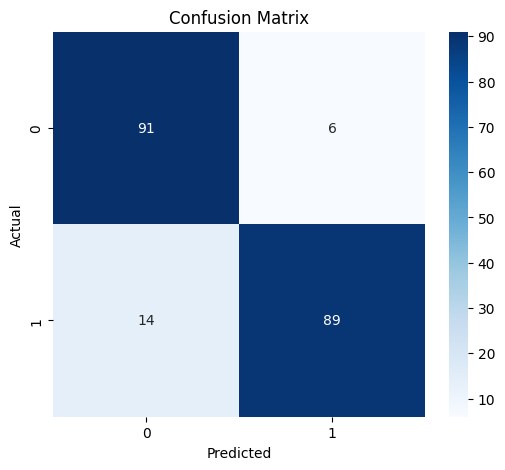

In [39]:
# Using seaborn heatmap
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Or using sklearn's built-in function
# from sklearn.metrics import ConfusionMatrixDisplay
# disp = ConfusionMatrixDisplay(confusion_matrix=cm)
# disp.plot(cmap='Blues')
# plt.show()


In [ ]:
#import joblib

#joblib.dump(knn, "knn_model.pkl")
#print("\nModel saved as knn_model.pkl")


First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Missing values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                       

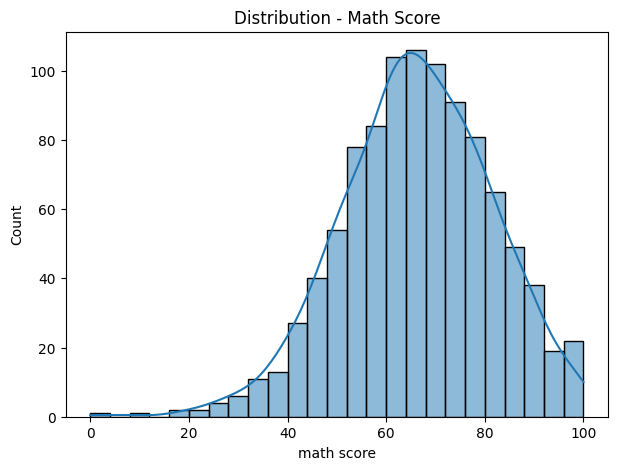

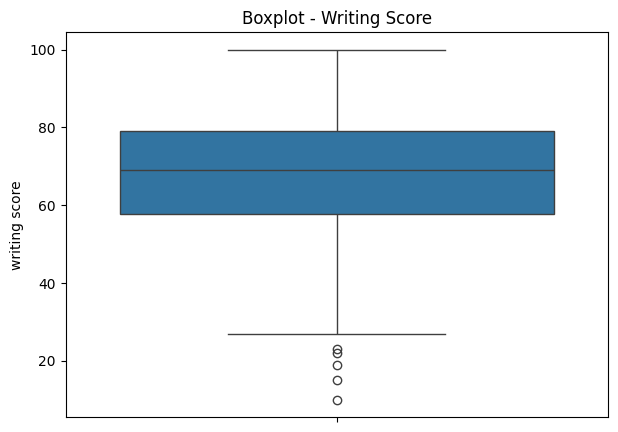

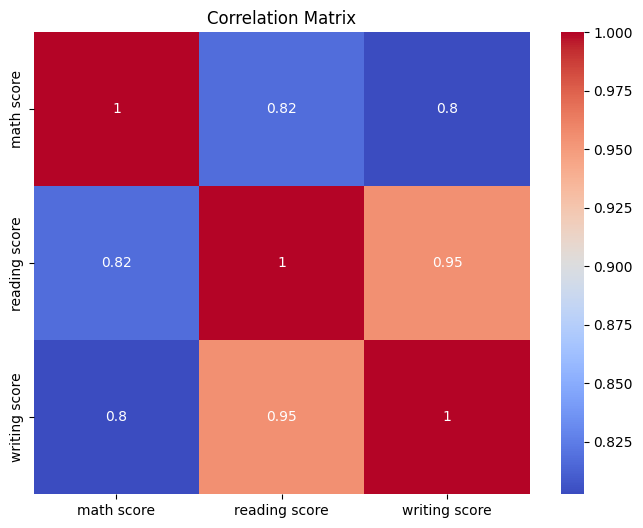

Insight: All three scores are strongly positively correlated.

--- Decision Tree Results ---
Accuracy: 0.9966666666666667
Confusion Matrix:
 [[168   1]
 [  0 131]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       169
           1       0.99      1.00      1.00       131

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Decision Tree model saved.


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# 1. Load dataset
df = pd.read_csv("StudentsPerformance.csv")
print("First 5 rows:")
print(df.head())

# 2. Missing values
print("\nMissing values:\n", df.isnull().sum())
df["math score"] = df["math score"].fillna(df["math score"].mean())

# 3. Distribution plot
plt.figure(figsize=(7,5))
sns.histplot(df["math score"], kde=True)
plt.title("Distribution - Math Score")
plt.show()

# 4. Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(y=df["writing score"])
plt.title("Boxplot - Writing Score")
plt.show()

# 5. Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
print("Insight: All three scores are strongly positively correlated.")

# 6. PCA (2 components)
X = df[["math score","reading score","writing score"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 7. Create target and split data
df["average"] = df[["math score","reading score","writing score"]].mean(axis=1)
df["result"] = np.where(df["average"] >= 70, 1, 0)
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

# 8. Train Decision Tree
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)

# 9. Evaluation
print("\n--- Decision Tree Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 10. Save model
joblib.dump(dt, "decision_tree_model.pkl")
print("\nDecision Tree model saved.")


First 5 rows:
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76             78             75  

Missing values:
 gender                         0
race/ethnicity                 0
parental level of education    0
lunch                       

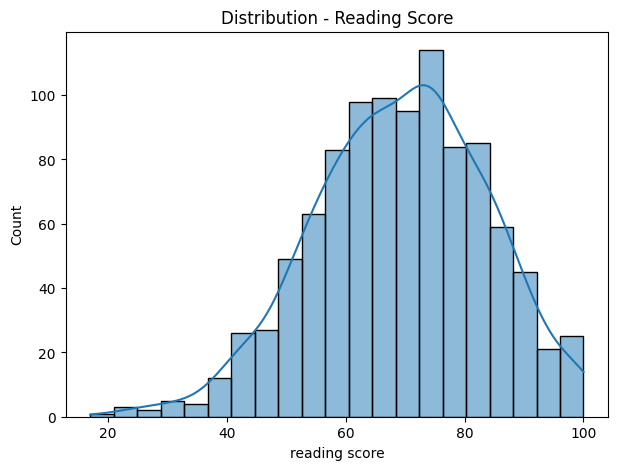

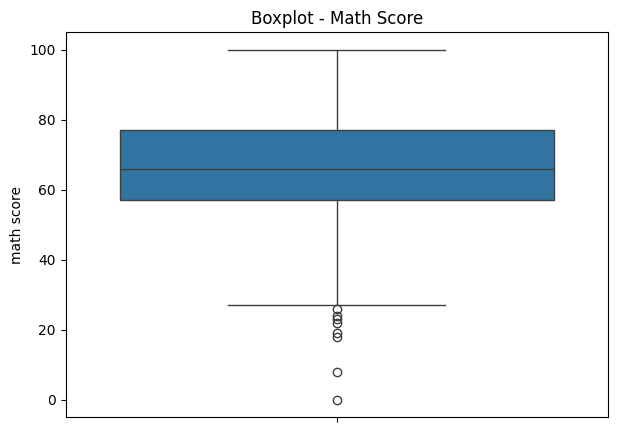

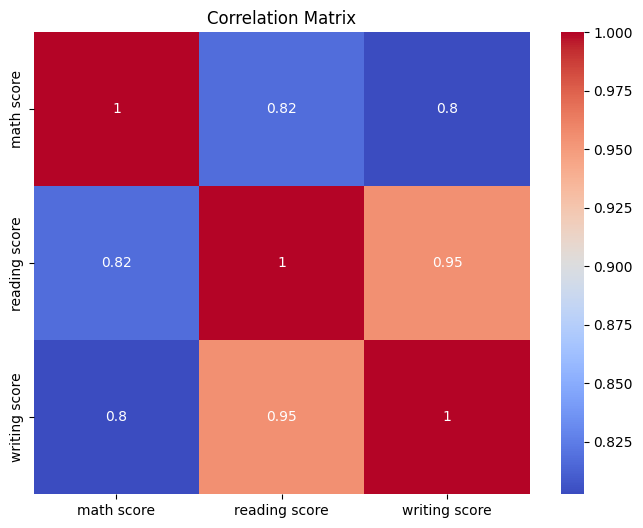

Insight: Reading and writing scores are highly correlated.

--- Gaussian Naive Bayes Results ---
Accuracy: 0.9966666666666667
Confusion Matrix:
 [[169   0]
 [  1 130]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      1.00       169
           1       1.00      0.99      1.00       131

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Gaussian Naive Bayes model saved.


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import joblib

# 1. Load dataset
df = pd.read_csv("StudentsPerformance.csv")
print("First 5 rows:")
print(df.head())

# 2. Missing values
print("\nMissing values:\n", df.isnull().sum())
df["math score"] = df["math score"].fillna(df["math score"].mean())

# 3. Distribution plot
plt.figure(figsize=(7,5))
sns.histplot(df["reading score"], kde=True)
plt.title("Distribution - Reading Score")
plt.show()

# 4. Boxplot
plt.figure(figsize=(7,5))
sns.boxplot(y=df["math score"])
plt.title("Boxplot - Math Score")
plt.show()

# 5. Correlation matrix
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
print("Insight: Reading and writing scores are highly correlated.")

# 6. PCA (2 components)
X = df[["math score","reading score","writing score"]]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 7. Create target and split data
df["average"] = df[["math score","reading score","writing score"]].mean(axis=1)
df["result"] = np.where(df["average"] >= 70, 1, 0)
y = df["result"]

X_train, X_test, y_train, y_test = train_test_split(
    X_pca, y, test_size=0.3, random_state=42
)

# 8. Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred = nb.predict(X_test)

# 9. Evaluation
print("\n--- Gaussian Naive Bayes Results ---")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# 10. Save model
joblib.dump(nb, "naive_bayes_model.pkl")
print("\nGaussian Naive Bayes model saved.")
